<a href="https://colab.research.google.com/github/Pranav-Trivedi20/MNIST-and-Fashion-MNIST-dataset-optimization/blob/main/Iris_and_Wine_dataset_Model_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Iris dataset
from sklearn.datasets import load_iris

# Train-test split
from sklearn.model_selection import train_test_split

# Training algorithm
from sklearn.linear_model import LogisticRegression

# Load dataset
iris = load_iris()

X = iris.data      # Features
y = iris.target    # Labels

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


#Exploratory Data Analysis:

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [4]:
print("Shape:", df.shape)
print(df.describe())

Shape: (150, 5)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [5]:
print(df["species"].value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


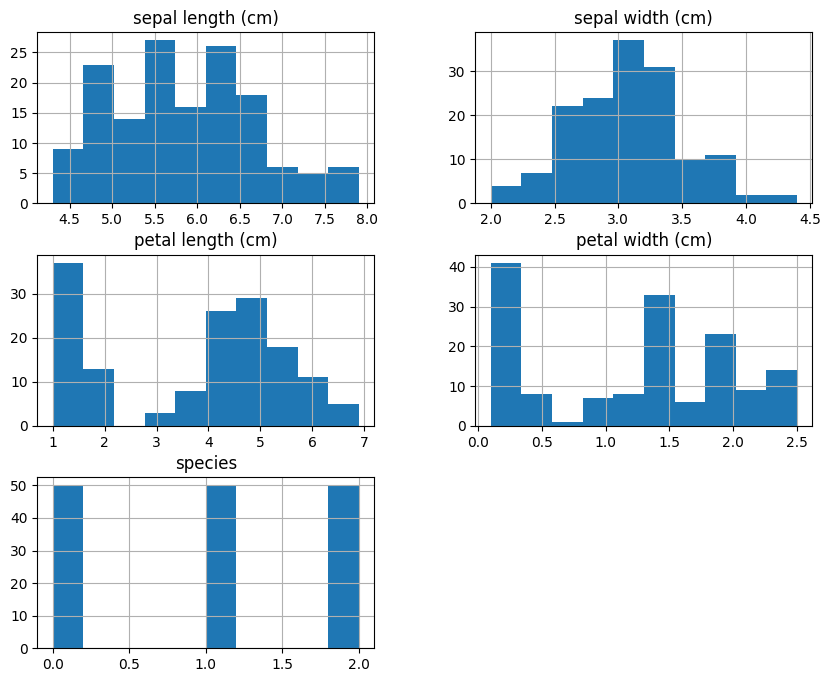

In [6]:
#Ploting Histogram
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

In [7]:
#Correlation Matrix
corr = df.iloc[:, :-1].corr()

print(corr)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


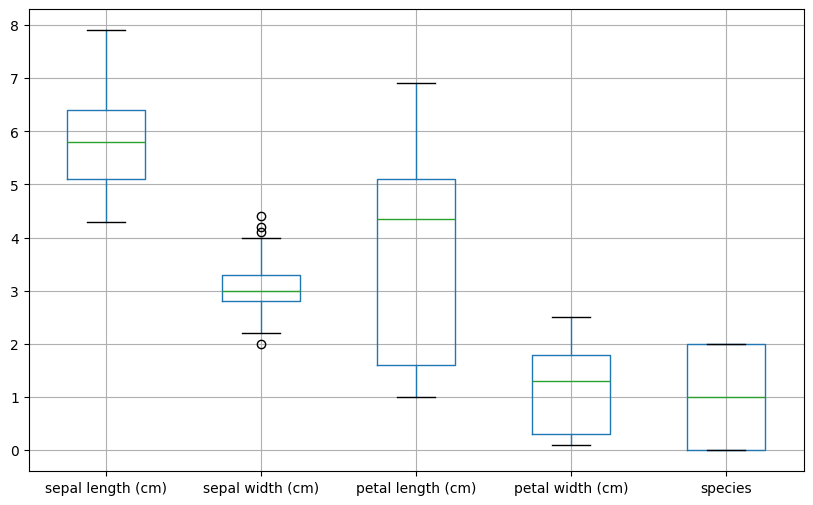

In [8]:
#Boxplot
df.boxplot(figsize=(10,6))
plt.show()

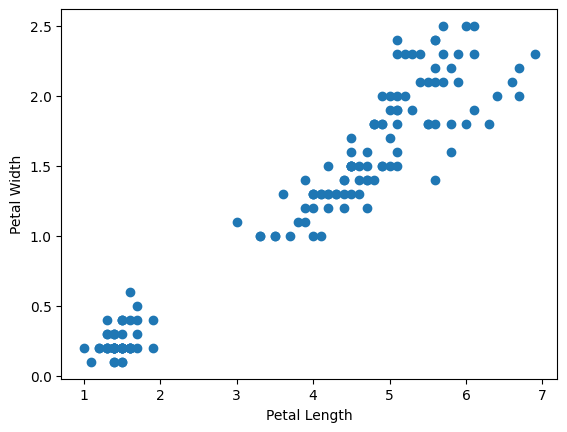

In [9]:
#Scatter plot
plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"]
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

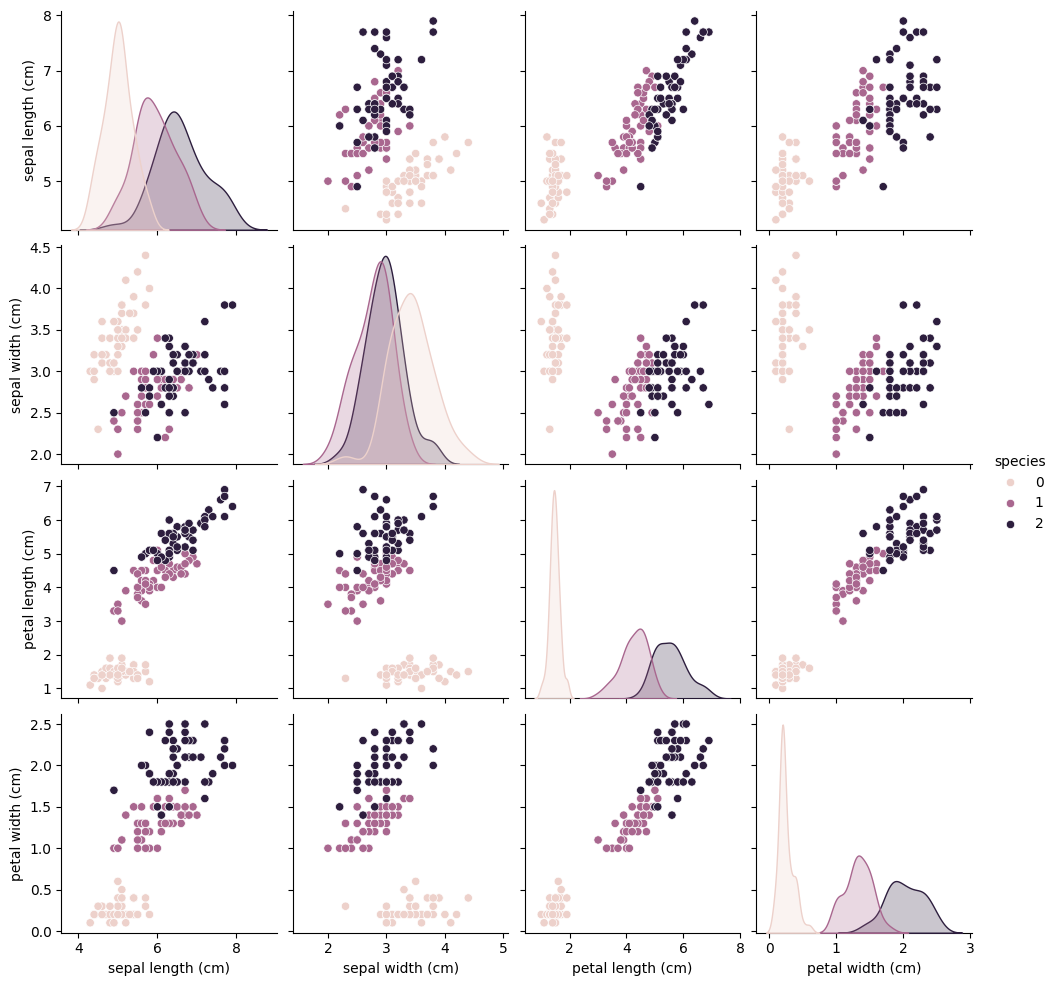

In [10]:
#pair plot
import seaborn as sns

sns.pairplot(
    df,
    hue="species"
)

plt.show()

In [11]:
# Feature names
print("Features:")
print(iris.feature_names)

# Target classes
print("\nClasses:")
print(iris.target_names)

# Dataset shape
print("\nDataset Shape:")
print("X:", X.shape)
print("y:", y.shape)

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Dataset Shape:
X: (150, 4)
y: (150,)


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [13]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [14]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#selecting 2 best features

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 2 features
selector = SelectKBest(score_func=f_classif, k=2)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [16]:
selected_features = [
    iris.feature_names[i]
    for i in range(len(iris.feature_names))
    if selector.get_support()[i]
]

print("Selected Features:")
print(selected_features)

Selected Features:
['petal length (cm)', 'petal width (cm)']


In [17]:
for name, score in zip(iris.feature_names, selector.scores_):
    print(f"{name}: {score:.2f}")

sepal length (cm): 84.81
sepal width (cm): 41.29
petal length (cm): 925.56
petal width (cm): 680.78


#Train Model Using Selected Features Only

In [18]:
from sklearn.linear_model import LogisticRegression

model_selected = LogisticRegression(max_iter=1000)

model_selected.fit(X_train_selected, y_train)

LogisticRegression(max_iter=1000)

#Evaluate Again

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_selected = model_selected.predict(X_test_selected)

print("Accuracy :", accuracy_score(y_test, y_pred_selected))
print("Precision:", precision_score(y_test, y_pred_selected, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_selected, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_selected, average='weighted'))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


##Now took wine dataset prune it and make similar to iris dataset(178,4). and again train the same model

In [20]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

print("Original Shape:", X.shape)   # (178, 13)

# Keep only first 4 features
X = X[:, :4]

print("Pruned Shape:", X.shape)     # (178, 4)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Wine model trained successfully!")

Original Shape: (178, 13)
Pruned Shape: (178, 4)
Wine model trained successfully!


In [57]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["target"] = wine.target

print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [58]:
#dataset overview
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [59]:
print(df.describe())

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

In [60]:
#class distribution
print(df["target"].value_counts())

target
1    71
0    59
2    48
Name: count, dtype: int64


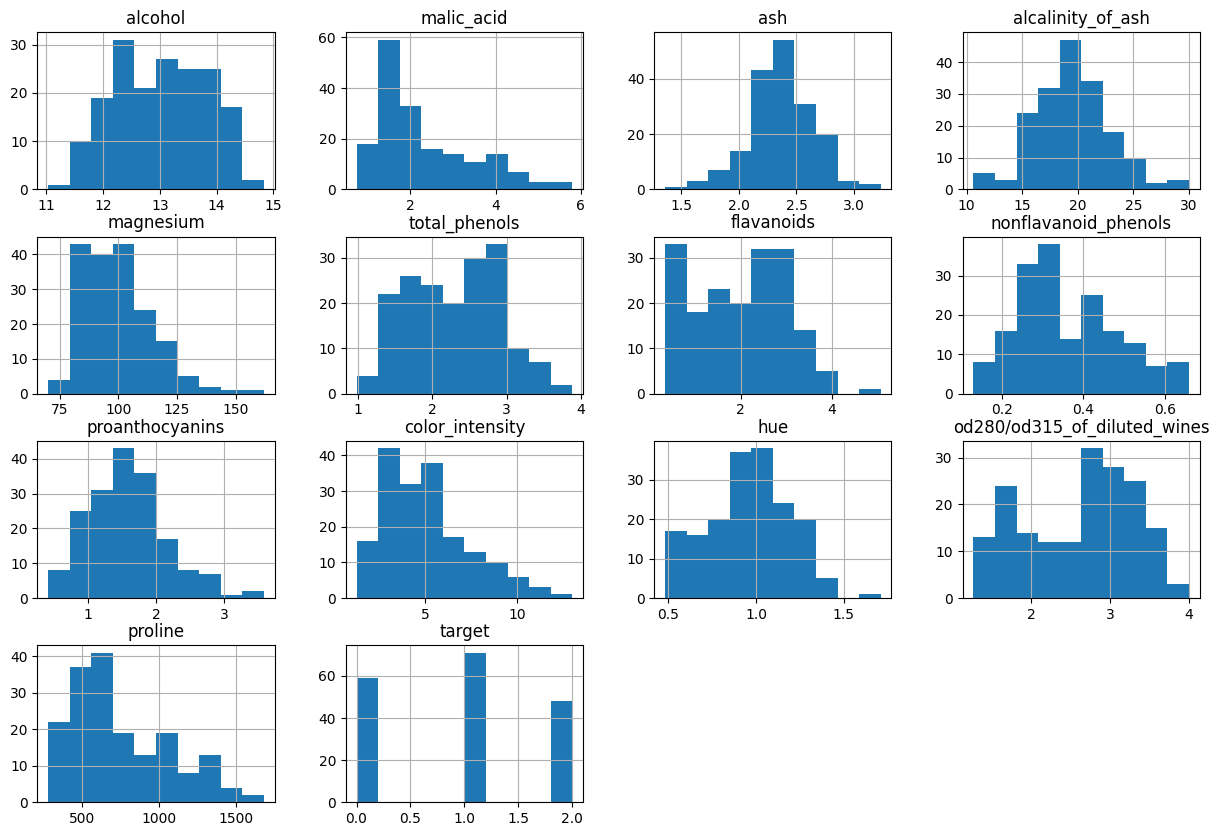

In [61]:
#histogram
import matplotlib.pyplot as plt

df.hist(figsize=(15,10))
plt.show()

In [62]:
#Correlation Matrix
corr = df.iloc[:, :-1].corr()

print(corr.round(2))

                              alcohol  malic_acid   ash  alcalinity_of_ash  \
alcohol                          1.00        0.09  0.21              -0.31   
malic_acid                       0.09        1.00  0.16               0.29   
ash                              0.21        0.16  1.00               0.44   
alcalinity_of_ash               -0.31        0.29  0.44               1.00   
magnesium                        0.27       -0.05  0.29              -0.08   
total_phenols                    0.29       -0.34  0.13              -0.32   
flavanoids                       0.24       -0.41  0.12              -0.35   
nonflavanoid_phenols            -0.16        0.29  0.19               0.36   
proanthocyanins                  0.14       -0.22  0.01              -0.20   
color_intensity                  0.55        0.25  0.26               0.02   
hue                             -0.07       -0.56 -0.07              -0.27   
od280/od315_of_diluted_wines     0.07       -0.37  0.00         

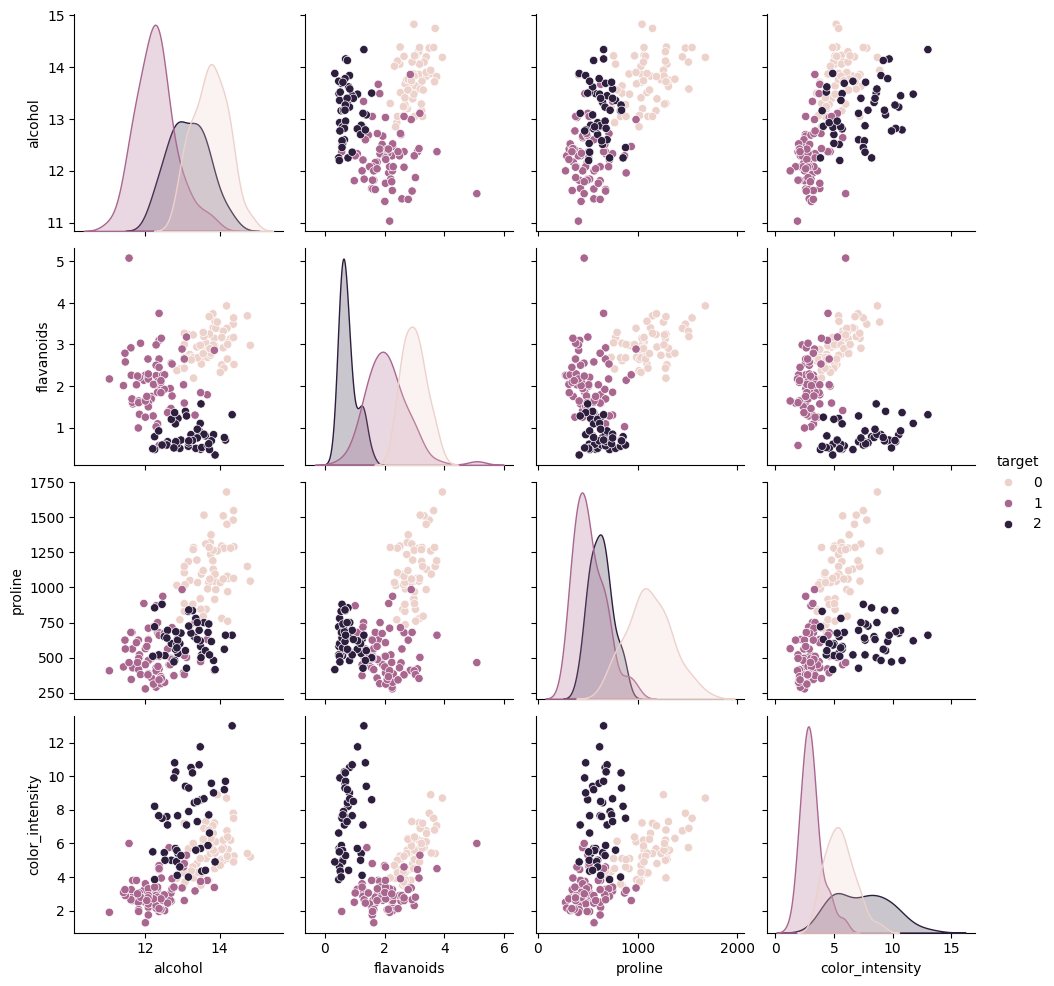

In [63]:
#Pair Plot
import seaborn as sns

sns.pairplot(
    df,
    hue="target",
    vars=[
        "alcohol",
        "flavanoids",
        "proline",
        "color_intensity"
    ]
)

plt.show()

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.8611111111111112
Precision: 0.8735042735042735
Recall   : 0.8611111111111112
F1 Score : 0.8641975308641974


In [22]:
print(confusion_matrix(y_test, y_pred))

[[12  0  2]
 [ 1 12  1]
 [ 0  1  7]]


In [23]:
print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

              precision    recall  f1-score   support

     class_0       0.92      0.86      0.89        14
     class_1       0.92      0.86      0.89        14
     class_2       0.70      0.88      0.78         8

    accuracy                           0.86        36
   macro avg       0.85      0.86      0.85        36
weighted avg       0.87      0.86      0.86        36



#Now perform feature selection

In [24]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 2 features
selector = SelectKBest(score_func=f_classif, k=2)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [25]:
selected_features = [
    wine.feature_names[:4][i]
    for i in range(4)
    if selector.get_support()[i]
]

print("Selected Features:")
print(selected_features)

Selected Features:
['alcohol', 'alcalinity_of_ash']


In [26]:
for name, score in zip(wine.feature_names[:4], selector.scores_):#feature score
    print(f"{name}: {score:.2f}")

alcohol: 89.65
malic_acid: 28.70
ash: 9.90
alcalinity_of_ash: 30.47


In [27]:
from sklearn.linear_model import LogisticRegression  #train using selected 2 features
model_selected = LogisticRegression(max_iter=1000)

model_selected.fit(X_train_selected, y_train)

LogisticRegression(max_iter=1000)

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_selected = model_selected.predict(X_test_selected)

print("Accuracy :", accuracy_score(y_test, y_pred_selected))
print("Precision:", precision_score(y_test, y_pred_selected, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_selected, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_selected, average='weighted'))

Accuracy : 0.8333333333333334
Precision: 0.8435897435897436
Recall   : 0.8333333333333334
F1 Score : 0.8353909465020575


As all the scores decresed

##CONCLUSION: Selecting 2 best features reduces performance of the model.
This shows that more features improves the model performance.

#Now we are using all 13 features of wine dataset.

In [29]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load Wine dataset
wine = load_wine()

# Use ALL 13 features
X = wine.data
y = wine.target

print("Dataset Shape:", X.shape)   # (178, 13)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LogisticRegression(max_iter=5000)

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Dataset Shape: (178, 13)
Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
#scaling as dataset cant converge with original values
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=5000))])

In [31]:
print("Features Used:")
for feature in wine.feature_names:
    print(feature)

Features Used:
alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline


In [32]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


# Using all features gives optimum results.
(Conc: More features better results.)

In [33]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [35]:
import time

start = time.time()

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

training_time = time.time() - start

print("Training Time:", training_time, "seconds")

Training Time: 8.045046091079712 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)




LogisticRegression(max_iter=5000)

Feature scaling improves optimization by helping gradient-based algorithms converge faster and more reliably, reducing training time and eliminating convergence issues.

#Now finding redundant features and eliminating them

In [37]:
#Method 1: Feature Importance using SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': wine.feature_names,
    'Score': selector.scores_
})

print(feature_scores.sort_values(
    by='Score',
    ascending=False
))

                         Feature       Score
6                     flavanoids  233.925873
12                       proline  207.920374
11  od280/od315_of_diluted_wines  189.972321
0                        alcohol  135.077624
9                color_intensity  120.664018
10                           hue  101.316795
5                  total_phenols   93.733010
1                     malic_acid   36.943425
3              alcalinity_of_ash   35.771637
8                proanthocyanins   30.271383
7           nonflavanoid_phenols   27.575417
2                            ash   13.312901
4                      magnesium   12.429584


In [38]:
#Correlation Matrix:Highly correlated features often contain similar information.
import pandas as pd

df = pd.DataFrame(X, columns=wine.feature_names)

corr_matrix = df.corr()

print(corr_matrix.round(2))

                              alcohol  malic_acid   ash  alcalinity_of_ash  \
alcohol                          1.00        0.09  0.21              -0.31   
malic_acid                       0.09        1.00  0.16               0.29   
ash                              0.21        0.16  1.00               0.44   
alcalinity_of_ash               -0.31        0.29  0.44               1.00   
magnesium                        0.27       -0.05  0.29              -0.08   
total_phenols                    0.29       -0.34  0.13              -0.32   
flavanoids                       0.24       -0.41  0.12              -0.35   
nonflavanoid_phenols            -0.16        0.29  0.19               0.36   
proanthocyanins                  0.14       -0.22  0.01              -0.20   
color_intensity                  0.55        0.25  0.26               0.02   
hue                             -0.07       -0.56 -0.07              -0.27   
od280/od315_of_diluted_wines     0.07       -0.37  0.00         

Strongly Correlated Features:
total_phenols ↔ flavanoids

flavanoids ↔ od280/od315_of_diluted_wines

In [39]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load dataset
wine = load_wine()

# Create DataFrame
import pandas as pd
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Remove 2 highly correlated features
X = df.drop(
    columns=[
        "flavanoids",
        "od280/od315_of_diluted_wines"
    ]
)

y = wine.target

print("New Shape:", X.shape)   # Should be (178, 11)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model_reduced = LogisticRegression(max_iter=5000)

model_reduced.fit(X_train_scaled, y_train)

print("Model trained successfully!")

New Shape: (178, 11)
Model trained successfully!


In [40]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

y_pred = model_reduced.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.9722222222222222
Precision: 0.9753086419753088
Recall   : 0.9722222222222222
F1 Score : 0.9725248123940935


with all 13 features:

Accuracy : 1.0

Precision: 1.0

Recall   : 1.0

F1 Score : 1.0

with 11 features:

Accuracy : 0.9722222222222222

Precision: 0.9753086419753088

Recall   : 0.9722222222222222

F1 Score : 0.9725248123940935
#(Conc: Althrough model score decreases but these are the most important 11 features.)
#eliminating any other instead of these 2 will reduce more score.

In [41]:
#Apply RFE to select top 5 features
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Base model
base_model = LogisticRegression(max_iter=5000)

# Select top 5 features
rfe = RFE(
    estimator=base_model,
    n_features_to_select=5
)

rfe.fit(X_train_scaled, y_train)

# Print selected features
selected_features = [
    feature
    for feature, keep in zip(
        wine.feature_names,
        rfe.support_
    )
    if keep
]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
['alcohol', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue']


In [42]:
#Create Dataset with Only Selected Features
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

print("Original Shape:", X_train_scaled.shape)
print("RFE Shape:", X_train_rfe.shape)

Original Shape: (142, 11)
RFE Shape: (142, 5)


In [43]:
#Train Model and Measure Training Time
import time
from sklearn.linear_model import LogisticRegression

start = time.time()

model_rfe = LogisticRegression(max_iter=5000)

model_rfe.fit(X_train_rfe, y_train)

training_time_rfe = time.time() - start

print("Training Time:", training_time_rfe)

Training Time: 0.015563726425170898


In [44]:
#Evaluate performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_rfe = model_rfe.predict(X_test_rfe)

print("Accuracy :", accuracy_score(y_test, y_pred_rfe))
print("Precision:", precision_score(
    y_test, y_pred_rfe,
    average='weighted'
))
print("Recall   :", recall_score(
    y_test, y_pred_rfe,
    average='weighted'
))
print("F1 Score :", f1_score(
    y_test, y_pred_rfe,
    average='weighted'
))

Accuracy : 0.9722222222222222
Precision: 0.9753086419753088
Recall   : 0.9722222222222222
F1 Score : 0.9725248123940935


accuracy with 11 features and accuracy with 5 features identical.
#Same accuracy, less time means  Excellent feature selection

#Hyperparameter Optimization:


In [45]:
#Trying different values of c
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time

C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:

    start = time.time()

    model = LogisticRegression(
        C=C,
        max_iter=5000
    )

    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print(
        f"C={C:6} | "
        f"Accuracy={accuracy:.4f} | "
        f"F1={f1:.4f} | "
        f"Time={training_time:.4f}s"
    )

C=  0.01 | Accuracy=1.0000 | F1=1.0000 | Time=0.0126s
C=   0.1 | Accuracy=1.0000 | F1=1.0000 | Time=0.0086s
C=     1 | Accuracy=0.9722 | F1=0.9725 | Time=0.0151s
C=    10 | Accuracy=0.9722 | F1=0.9725 | Time=0.0125s
C=   100 | Accuracy=0.9722 | F1=0.9725 | Time=0.0183s


In [46]:
#Using Cross Validation
from sklearn.model_selection import cross_val_score

for C in [0.01, 0.1, 1, 10, 100]:

    model = LogisticRegression(
        C=C,
        max_iter=5000
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5
    )

    print(
        f"C={C} | "
        f"Mean Accuracy={scores.mean():.4f}"
    )

C=0.01 | Mean Accuracy=0.9645
C=0.1 | Mean Accuracy=0.9648
C=1 | Mean Accuracy=0.9719
C=10 | Mean Accuracy=0.9719
C=100 | Mean Accuracy=0.9648


In [47]:
#Finding best parameter
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)

Best Parameters: {'C': 1}
Best CV Score : 0.97192118226601


##Small C underfitting

##Large C overfitting

## We need to find a balance.

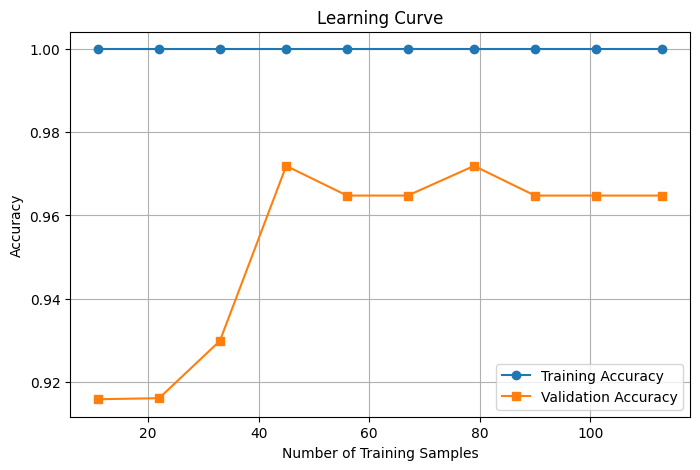

In [48]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    marker='s',
    label='Validation Accuracy'
)

plt.title("Learning Curve")
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend(loc="best")

plt.show()

##Conc: This graph converges at 45 to 50% of traing examples suggests that training data size and the dataset size both can be reduced.
(reducing training time )

#Now Comaparing Different Algorithms

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score
import time

In [50]:
#Create Model
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

In [51]:
#Comparing
for name, model in models.items():

    start = time.time()

    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print(f"\n{name}")
    print("Accuracy :", round(accuracy, 4))
    print("F1 Score :", round(f1, 4))
    print("Time     :", round(training_time, 4), "seconds")


Logistic Regression
Accuracy : 0.9722
F1 Score : 0.9725
Time     : 0.0126 seconds

KNN
Accuracy : 0.9444
F1 Score : 0.9436
Time     : 0.0047 seconds

Decision Tree
Accuracy : 0.9167
F1 Score : 0.9159
Time     : 0.003 seconds

Random Forest
Accuracy : 1.0
F1 Score : 1.0
Time     : 0.2071 seconds

SVM
Accuracy : 1.0
F1 Score : 1.0
Time     : 0.0025 seconds


##SVM is the best one in this case : Most accurate, least Time.

# Effects of Scaling:

In [52]:

#Create Scaled Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
#Comparing without scaling
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

print("WITHOUT SCALING\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(
        name,
        "Accuracy:",
        round(accuracy_score(y_test, y_pred), 4)
    )

WITHOUT SCALING

Logistic Regression Accuracy: 1.0
KNN Accuracy: 0.7222
SVM Accuracy: 0.7778


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [54]:
#Compare WITH Scaling
print("\nWITH SCALING\n")

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    print(
        name,
        "Accuracy:",
        round(accuracy_score(y_test, y_pred), 4)
    )


WITH SCALING

Logistic Regression Accuracy: 0.9722
KNN Accuracy: 0.9444
SVM Accuracy: 1.0


In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    # Without scaling
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc_without = accuracy_score(y_test, y_pred)

    # With scaling
    model.fit(X_train_scaled, y_train)
    y_pred_scaled = model.predict(X_test_scaled)

    acc_with = accuracy_score(y_test, y_pred_scaled)

    results.append([
        name,
        round(acc_without, 4),
        round(acc_with, 4)
    ])

# Create table
comparison_table = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Without Scaling",
        "With Scaling"
    ]
)

print(comparison_table)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


             Algorithm  Without Scaling  With Scaling
0  Logistic Regression           1.0000        0.9722
1                  KNN           0.7222        0.9444
2                  SVM           0.7778        1.0000
3        Decision Tree           0.9167        0.9167
4        Random Forest           1.0000        1.0000


#CONC: Scaling improves results in LR,KNN and SVM while in tree basd algorithms no effect of scaling.

In [64]:
#Compare Mean and Standard Deviation
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

print(df.groupby("species").agg(['mean', 'std']))

        sepal length (cm)           sepal width (cm)            \
                     mean       std             mean       std   
species                                                          
0                   5.006  0.352490            3.428  0.379064   
1                   5.936  0.516171            2.770  0.313798   
2                   6.588  0.635880            2.974  0.322497   

        petal length (cm)           petal width (cm)            
                     mean       std             mean       std  
species                                                         
0                   1.462  0.173664            0.246  0.105386  
1                   4.260  0.469911            1.326  0.197753  
2                   5.552  0.551895            2.026  0.274650  


In [65]:
#Compare Feature Variability
print(df.iloc[:, :-1].std().sort_values(ascending=False))

petal length (cm)    1.765298
sepal length (cm)    0.828066
petal width (cm)     0.762238
sepal width (cm)     0.435866
dtype: float64


In [66]:
#ANOVA Test
from scipy.stats import f_oneway

for feature in iris.feature_names:

    setosa = df[df["species"] == 0][feature]
    versicolor = df[df["species"] == 1][feature]
    virginica = df[df["species"] == 2][feature]

    F, p = f_oneway(
        setosa,
        versicolor,
        virginica
    )

    print(feature)
    print("F =", round(F,2))
    print("p =", p)
    print()

sepal length (cm)
F = 119.26
p = 1.6696691907693826e-31

sepal width (cm)
F = 49.16
p = 4.492017133309115e-17

petal length (cm)
F = 1180.16
p = 2.8567766109619814e-91

petal width (cm)
F = 960.01
p = 4.169445839443833e-85



#Principle Component Analysis(PCA)

In [67]:
#Scale Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
#Apply PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(X_train_pca.shape)

(142, 5)


###Reduced 13 features to 5 components.

In [69]:
print(pca.explained_variance_ratio_)

[0.30370209 0.21557355 0.12312402 0.08037644 0.07680037]


In [70]:
print(
    "Total Variance Preserved:",
    pca.explained_variance_ratio_.sum()
)

Total Variance Preserved: 0.7995764646970664


In [71]:
#Train Model on PCA features
from sklearn.linear_model import LogisticRegression

model_pca = LogisticRegression(max_iter=5000)

model_pca.fit(X_train_pca, y_train)

LogisticRegression(max_iter=5000)

In [72]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = model_pca.predict(X_test_pca)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("F1 Score:",
      f1_score(
          y_test,
          y_pred,
          average='weighted'
      ))

Accuracy: 1.0
F1 Score: 1.0
